In [5]:
!pip install statsforecast

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, SeasonalNaive, Naive

In [10]:
# 1. Tạo dữ liệu giả lập (Sửa np.range thành np.arange)
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
sales = 200 + np.arange(100) * 0.5 + 20 * np.sin(2 * np.pi * dates.dayofyear / 30) + np.random.normal(0, 5, 100)

In [12]:
df = pd.DataFrame({
    'unique_id': 'store_1',
    'ds': dates,
    'y': sales
})

In [13]:
df.head()

,unique_id,ds,y
0,store_1,2020-01-01,199.159000
1,store_1,2020-01-02,207.010504
2,store_1,2020-01-03,210.803120
3,store_1,2020-01-04,223.758376
4,store_1,2020-01-05,215.374054


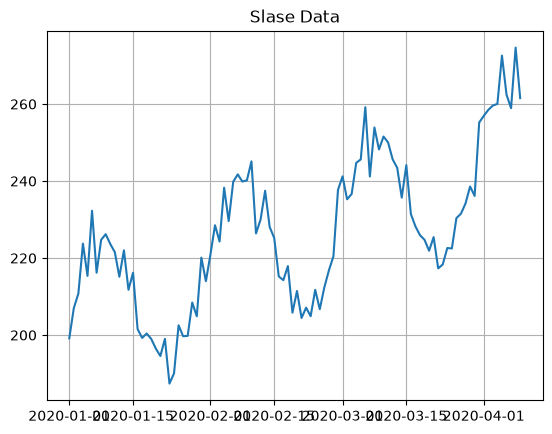

In [15]:
plt.plot(df['ds'], df['y'], label="sales")
plt.title("Slase Data")
plt.grid(True)

In [17]:
horizon = 14
train_df = df[:-horizon]
test_df = df[-horizon:]

In [18]:
len(train_df)

86

In [19]:
len(test_df)

14

In [20]:
models = [AutoARIMA(), AutoETS(), Naive(), SeasonalNaive(season_length=30)]

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
# 1. Khởi tạo StatsForecast (chỉ truyền models và freq, KHÔNG truyền df ở đây)
sf = StatsForecast(
    models=models,
    freq='D'
)

# 2. Huấn luyện mô hình bằng hàm fit() truyền DataFrame vào
sf.fit(df)

# 3. Dự báo cho 14 ngày tiếp theo
forecast_df = sf.predict(h=horizon)

print(forecast_df.head())

# 4. Vẽ đồ thị kết quả
sf.plot(df, forecast_df, unique_ids=['store_1'])
plt.show()

  unique_id         ds   AutoARIMA     AutoETS       Naive  SeasonalNaive
0   store_1 2020-04-10  263.605441  266.309295  261.534967     250.032166
1   store_1 2020-04-11  262.604179  265.467022  261.534967     245.640300
2   store_1 2020-04-12  261.810707  264.705528  261.534967     243.456650
3   store_1 2020-04-13  261.181904  264.017067  261.534967     235.701293
4   store_1 2020-04-14  260.683596  263.394633  261.534967     244.122213


In [25]:

def plot_forecast(train, test, forecast, model_name):
    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], test["y"], label="Actual", color="black")
    plt.plot(test["ds"], forecast[model_name].values, label=f"Forecast - {model_name}")
    plt.title(f"{model_name} Forecast vs Actual")
    plt.grid(True)
    plt.show()

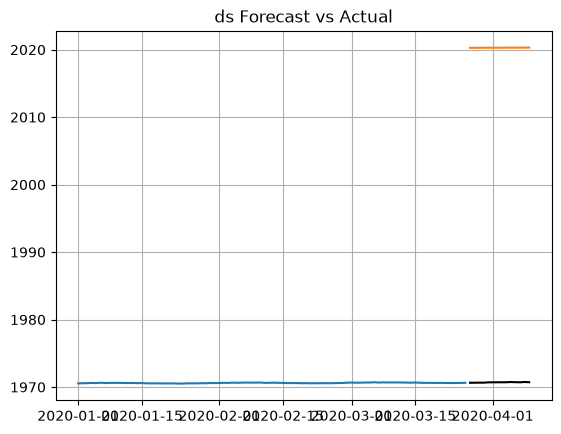

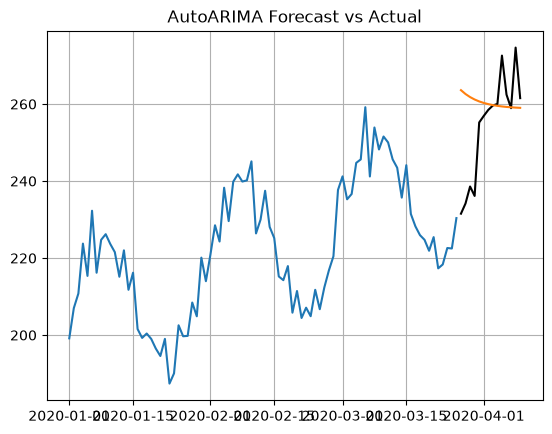

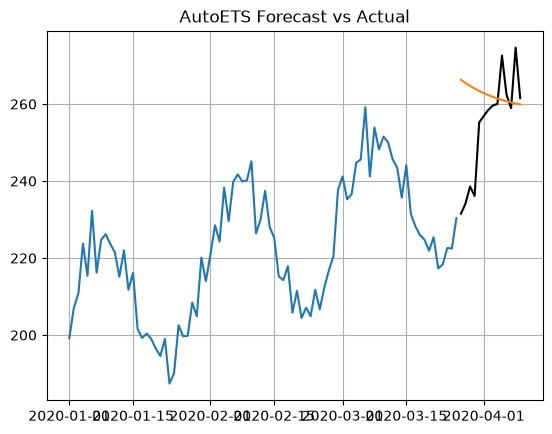

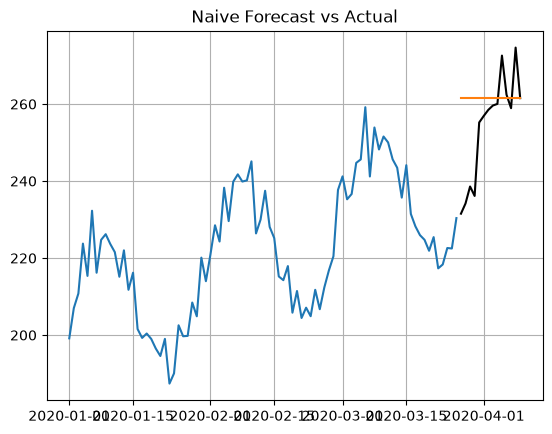

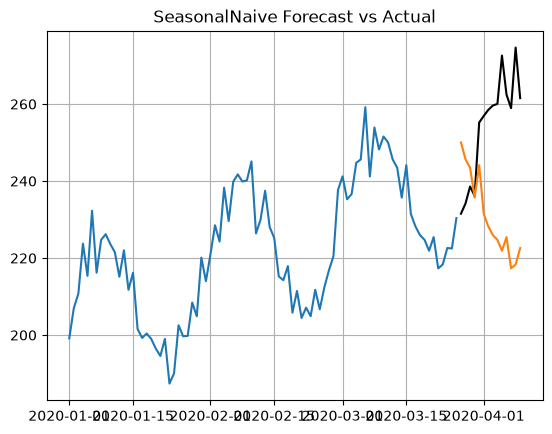

In [26]:
for model in forecast_df.columns[1:]:
    plot_forecast(train_df, test_df, forecast_df, model)

  unique_id         ds   AutoARIMA     AutoETS       Naive  SeasonalNaive
0   store_1 2020-03-27  229.157556  229.944792  233.603903     211.592142
1   store_1 2020-03-28  232.862454  229.944792  233.603903     226.862001
2   store_1 2020-03-29  235.320977  229.944792  233.603903     224.078946
3   store_1 2020-03-30  236.952422  229.944792  233.603903     228.751048
4   store_1 2020-03-31  238.035028  229.944792  233.603903     243.104254


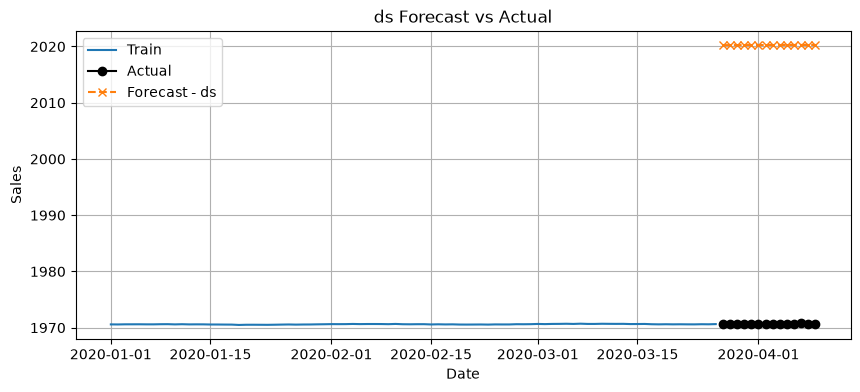

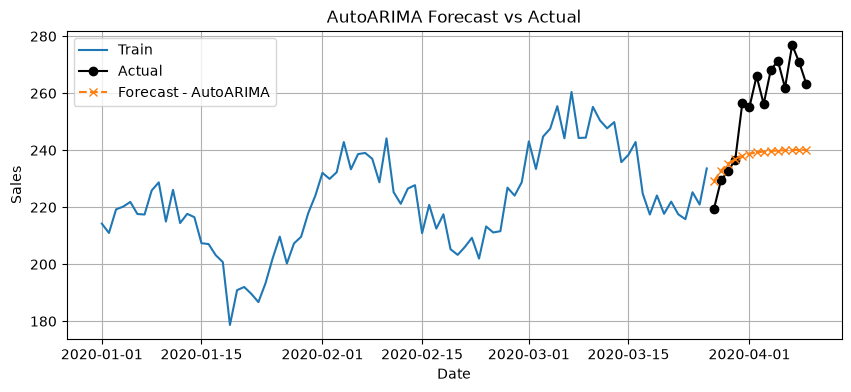

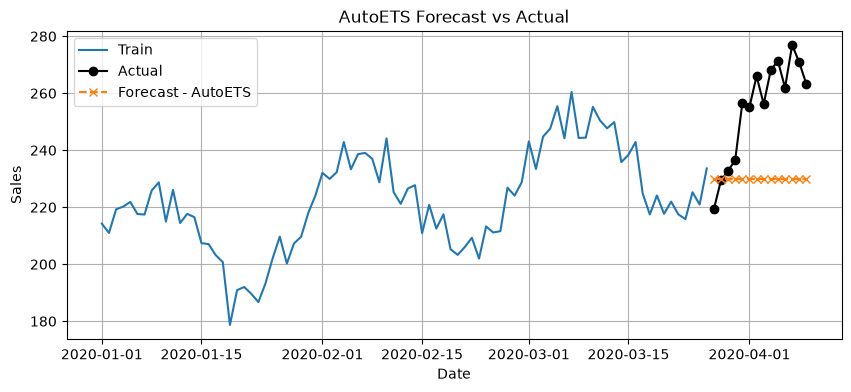

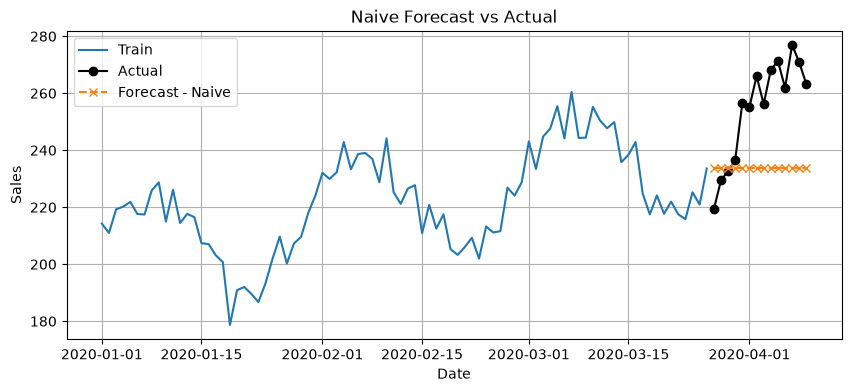

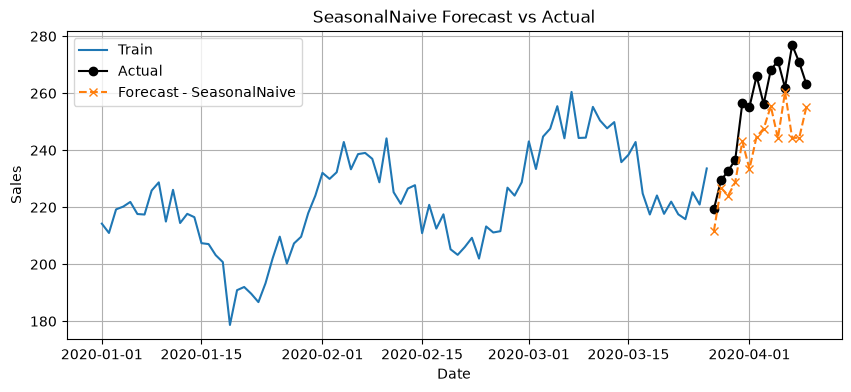

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Naive, SeasonalNaive
import warnings
warnings.filterwarnings("ignore")

# 1. Tạo dữ liệu giả lập
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
sales = 200 + np.arange(100) * 0.5 + 20 * np.sin(2 * np.pi * dates.dayofyear / 30) + np.random.normal(0, 5, 100)
df = pd.DataFrame({
    'unique_id': 'store_1',
    'ds': dates,
    'y': sales
})

# Chia train / test
horizon = 14
train_df = df[:-horizon]
test_df = df[-horizon:]

# 2. Khởi tạo và Huấn luyện mô hình CHỈ trên train_df
models = [AutoARIMA(), AutoETS(), Naive(), SeasonalNaive(season_length=30)]
sf = StatsForecast(
    models=models,
    freq='D'
)

sf.fit(train_df)

# 3. Dự báo cho khoảng thời gian của test_df (h = 14)
forecast_df = sf.predict(h=len(test_df))

print(forecast_df.head())

# 4. Vẽ đồ thị tổng quan từ sf.plot (lưu ý: truyền train_df vào thay vì df để khớp thực tế)
sf.plot(train_df, forecast_df, unique_ids=['store_1'])
plt.show()

# 5. Hàm vẽ so sánh chi tiết từng mô hình với test thực tế
def plot_forecast(train, test, forecast, model_name):
    plt.figure(figsize=(10, 4))
    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], test["y"], label="Actual", color="black", marker='o')
    plt.plot(test["ds"], forecast[model_name].values, label=f"Forecast - {model_name}", linestyle='--', marker='x')
    plt.title(f"{model_name} Forecast vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

for model in forecast_df.columns[1:]:
    plot_forecast(train_df, test_df, forecast_df, model)